In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.data import load_csv_df, save_processed_artifacts
from src.plotting import set_plotting_style

In [ ]:
# Already prepared accent palette applying using function from mine src module (plotting)
set_plotting_style()

In [ ]:
DF_PATH = "../data/raw/raw-data.csv"

# Safely loading dataframe using function from mine src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

In [ ]:
df = df.set_index("Country name")
display(df.head(5)) # Index replaces with "Country name" identifier

In [ ]:
num_col = df.select_dtypes(include="number").columns
df = df[num_col].fillna(df[num_col].median())
print(f"Missing: {df.isna().sum().sum()} values")

In [ ]:
duplicated_cols = ["Total in km2", "% of world population"]
df_prep = df.drop(columns=duplicated_cols)
print(df_prep.columns)

In [ ]:
num_col = df_prep.select_dtypes(include="number").columns
skewed_cols = [col for col in num_col if col != "HDI"]
df_prep[skewed_cols] = np.log1p(df_prep[skewed_cols])

df_skewness = df_prep[skewed_cols].skew()
print(df_skewness.sort_values(ascending=False)) # Columns successfully log-transformed

In [ ]:
df_prep["Land per capita"] = df_prep["Land in km2"] / df_prep["Population"]
df_prep["Dev demographic index"] = df_prep["HDI"] / df_prep["Fertility rate"]
"""Feature engineering:
----------------------------
1. "Land per capita" (Land in km2 / Population):
    - Measure how much physical land area exists each person in a country.
    - Helps model clearly group huge, low density country and seperate them.
2. "Dev demographic index" (HDI / Fertility rate):
    - Combines a country's quality of life and birth rate into a simple score.
    - Rich, developed countries with low birth rates get a high score,
    while developing countries with high birth rates get a low score.
"""

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep)

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=df_prep.index,
    columns=df_prep.columns,
)

print(f"Processed dataframe Shape: {X_scaled_df.shape}")
display(X_scaled_df.head(5)) # Data successfully scaled

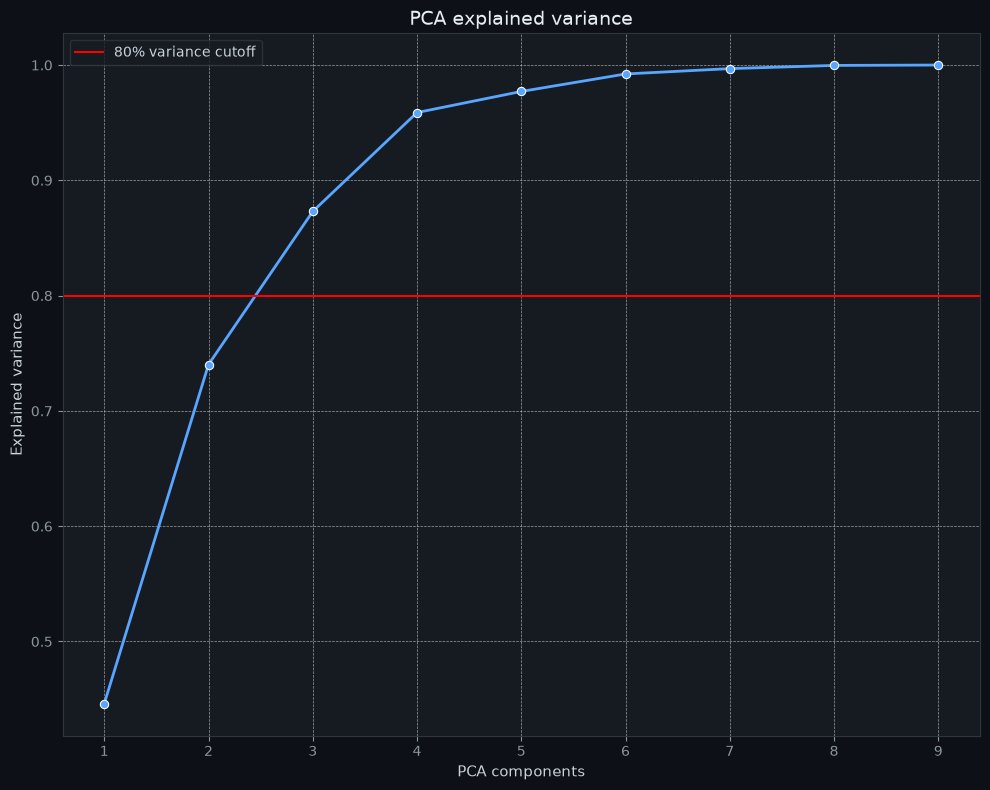

In [13]:
pca = PCA(random_state=42)
X_pca = pca.fit(X_scaled_df)
cum_varies = np.cumsum(X_pca.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
sns.lineplot(
    x=range(1, len(cum_varies) + 1),
    y=cum_varies,
    marker="o",
    linewidth=2
)
plt.axhline(y=0.8, color="red", linestyle="-", label="80% variance cutoff")
plt.title("PCA explained variance")
plt.xlabel("PCA components")
plt.ylabel("Explained variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() # The best n_components is 4 (approximately 0.95% explained variance)

In [ ]:
BEST_N_COMPONENTS = 3

pca_3 = PCA(
    n_components=BEST_N_COMPONENTS,
    random_state=42
)
X_pca_3 = pca_3.fit_transform(X_scaled_df)

X_pca_df = pd.DataFrame(
    X_pca_3,
    columns=["PCA1", "PCA2", "PCA3"],
    index=X_scaled_df.index,
)
display(X_pca_df.head(5)) # Successfully information reduced

In [ ]:
DATA_DIR = "../data/processed/"
MODEL_DIR = "../models/"

# Save processed dfs and model artifacts using function from mine src module (data)
save_processed_artifacts(
    scaled_df=X_scaled_df,
    pca_df=X_pca_df,
    scaler_obj=scaler,
    pca_obj=pca_3,
    data_output_path=DATA_DIR,
    model_output_path=MODEL_DIR
)

# 🔧 FE Summary

---

### 1. Data cleaning and feature engineering
* **Missing values:** handled missing values in numerical columns with medians.
* **Feature dropping:** removed multicollinear features (`Total in km2`, `% of world population`)
* **Log transformation:** applied log transformation across highly skewed features (excluding `HDI`).
* **Domain feature creation:**
    * `Land per capita` - `Land in km2` / `Population` (captures physical land density per city).
    * `Dev demographic index` - `HDI` / `Fertility rate` (combines quality of life and birth rate into single score).

---

### 2. Standardization & PCA
* **Feature Scaling:** Scaled all features using `StandartScaler`.
* **Dimensionality reduction:** selected PCA 3 main components (`PCA1`, `PCA2`, `PCA3`) based on cumulative explained variance:
    * `PCA1`: ***44%*** explained
    * `PCA1` + `PCA2`: ***75%*** explained
    * `PCA1` + `PCA2` + `PCA3`: ***87%*** explained

---

### 3. Artifact management
* Saved transformed datasets (`scaled_df.csv`, `pca_df.csv`) to `../data/processed/`.
* Exported preprocessors (`scaler.pkl`, `pca.pkl`) to `../models/` using `save_processed_artifacts`.

---

### ⚙️ Cluster Selection
Proceed with comparative clustering analysis across multiple models:

1. **K-Means:**
    * Evaluate optimal `n_clusters` on `X_pca_df` using **Inertia (Elbow method)** and **Silhouette Score**.
2. **DBSCAN and HDBSCAN:**
    * **DBSCAN:** Tune `eps` and `min_samples` to easily cluster cores and noises.
    * **HDBSCAN:** Tune `min_sample_size` and `min_samples` for precise clustering.
3. **Model evaluation and comparison:**
    * Compare Silhouette, Davies-Bouldin and Calinski-Harabasz metrics across all models.
    * Profile country cluster characteristics and analyze.